In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

C:\Users\manoj\PycharmProjects\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()

True

In [5]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

subgraph_llm = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

In [7]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

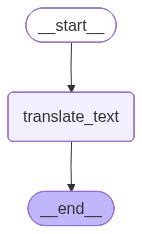

In [8]:
# Subgraph

subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()
subgraph

In [9]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str


In [10]:
parent_llm = ChatGoogleGenerativeAI(model='gemini-3-flash-preview')

In [11]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [12]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [13]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

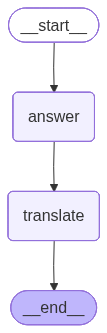

In [14]:
graph = parent_builder.compile()

graph

In [15]:
res = graph.invoke({'question': 'What is quantum physics'})

In [20]:
print("Answer - ENG: ", res['answer_eng'][0]['text'])
print("Answer - HND: ", res['answer_hin'][0]['text'])

Answer - ENG:  Quantum physics (also known as quantum mechanics) is the branch of science that studies the behavior of matter and energy at the most fundamental level: **atoms and subatomic particles.**

While classical physics (like Isaac Newton’s laws) explains how a ball bounces or how planets move, it fails completely when things get very, very small. At the atomic scale, the universe follows a different, often "weird" set of rules.

Here are the core concepts that define quantum physics:

### 1. Energy comes in "packets" (Quanta)
In our everyday world, things seem continuous—like a ramp you can stand on at any height. In the quantum world, energy is "quantized," meaning it comes in specific, tiny chunks called **quanta**. It’s more like a staircase; you can stand on the first step or the second step, but never in between.

### 2. Wave-Particle Duality
One of the most famous discoveries in quantum physics is that everything has both "particle" and "wave" properties. 
*   **Light** 